# Aula 1 – Machine Learning Aplicada à Indústria
## Notebook do Aluno

**Nome:** Washington Fernandes de Barros
**Data:** 05/09/2026

### Objetivo da aula
- compreender o problema industrial;
- ler a base de dados;
- identificar faltantes, duplicatas e possíveis outliers;
- registrar observações que serão usadas no pré-processamento.


## 1. Importação das bibliotecas

Complete a célula abaixo com as bibliotecas que serão usadas.


In [35]:
# Complete:
# importar pandas
# importar numpy
# importar matplotlib.pyplot como plt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


## 2. Leitura da base

Complete com o nome do arquivo e carregue o dataset.


In [36]:
arquivo='/content/dados_aula1_machine_learning_industria.csv'
df=pd.read_csv(arquivo)

## 3. Visualização inicial

Mostre as primeiras linhas da base e registre abaixo o que você percebe.

**Anotações do aluno:**  
- A tabela possui colunas numéricas e categóricas.
- A tabela possui valores ausentes (NaN).
- A coluna timestamp indica que os dados são medições feitas de hora em hora, a partir de 10/01/2026.


In [37]:
# Complete para visualizar as primeiras linhas
df.head()

,timestamp,lote_producao,operador,modo_controle,status_valvula,setpoint_vazao_l_min,vazao_medida_l_min,pressao_linha_bar,temperatura_processo_c,abertura_valvula_pct,vibracao_bomba_mm_s,tempo_resposta_ms,ph_produto,densidade_produto_g_cm3,status_instrumentacao
0,2026-01-10 08:00:00,Lote_A,op_b,automatico,normal,121.44,128.08,3.518,95.00,56.97,2.960,220.8,7.09,1.069,estavel
1,2026-01-10 09:00:00,Lote_D,op_c,cascata,normal,126.17,119.32,4.616,43.34,63.26,2.532,402.1,6.99,1.053,inspecao
2,2026-01-10 10:00:00,Lote_B,op_d,manual,intermitente,128.54,129.11,4.118,40.67,63.14,2.182,284.1,6.72,1.021,inspecao
3,2026-01-10 11:00:00,Lote_C,op_a,automatico,intermitente,106.50,102.68,3.547,43.94,64.75,2.772,486.3,6.67,1.093,inspecao
4,2026-01-10 12:00:00,Lote_C,op_a,automatico,normal,101.59,NaN,4.085,102.00,83.82,3.173,283.3,6.66,1.004,estavel


## 4. Tipos de dados
Verifique os tipos das colunas e descreva quais são numéricas e quais são categóricas.

Anotações do aluno:

**Colunas numéricas:** setpoint_vazao_l_min, vazao_medida_l_min, pressao_linha_bar, temperatura_processo_c, abertura_valvula_pct, vibracao_bomba_mm_s, tempo_resposta_ms, ph_produto, densidade_produto_g_cm3

**Colunas categóricas:** lote_producao, operador, modo_controle, status_valvula, status_instrumentacao

**Coluna data/hora:** timestamp

In [38]:
print(df.select_dtypes(include=['number']).columns.tolist())
print(df.select_dtypes(include=['object']).columns.tolist())

['setpoint_vazao_l_min', 'vazao_medida_l_min', 'pressao_linha_bar', 'temperatura_processo_c', 'abertura_valvula_pct', 'vibracao_bomba_mm_s', 'tempo_resposta_ms', 'ph_produto', 'densidade_produto_g_cm3']
['timestamp', 'lote_producao', 'operador', 'modo_controle', 'status_valvula', 'status_instrumentacao']


In [39]:
# Complete para exibir informações gerais da base
print(df.info())
print(df.dtypes)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188 entries, 0 to 187
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   timestamp                188 non-null    object 
 1   lote_producao            188 non-null    object 
 2   operador                 183 non-null    object 
 3   modo_controle            183 non-null    object 
 4   status_valvula           188 non-null    object 
 5   setpoint_vazao_l_min     188 non-null    float64
 6   vazao_medida_l_min       176 non-null    float64
 7   pressao_linha_bar        178 non-null    float64
 8   temperatura_processo_c   178 non-null    float64
 9   abertura_valvula_pct     188 non-null    float64
 10  vibracao_bomba_mm_s      188 non-null    float64
 11  tempo_resposta_ms        177 non-null    float64
 12  ph_produto               180 non-null    float64
 13  densidade_produto_g_cm3  188 non-null    float64
 14  status_instrumentacao    1

## 5. Estatísticas descritivas

Gere estatísticas descritivas das variáveis numéricas.


In [40]:
# Complete
df.describe(include=[np.number]).T

,count,mean,std,min,25%,50%,75%,max
setpoint_vazao_l_min,188.0,119.056277,12.164116,90.340,110.3375,119.2300,126.9200,156.950
vazao_medida_l_min,176.0,119.571761,13.808622,90.230,110.2875,118.5650,128.7800,160.330
pressao_linha_bar,178.0,3.954781,0.842332,2.811,3.5655,3.8865,4.1190,10.200
temperatura_processo_c,178.0,43.874213,9.399248,26.070,40.0275,43.1750,46.6650,110.000
abertura_valvula_pct,188.0,58.468617,16.380992,18.010,46.7575,58.6000,67.7500,99.280
vibracao_bomba_mm_s,188.0,2.336059,0.958364,0.386,1.7935,2.2900,2.7210,9.100
tempo_resposta_ms,177.0,337.286441,129.197193,130.100,278.2000,321.4000,377.5000,1500.000
ph_produto,180.0,6.806500,0.312416,6.040,6.6100,6.8200,7.0125,7.560
densidade_produto_g_cm3,188.0,1.040255,0.030946,0.949,1.0210,1.0395,1.0620,1.134


## 6. Valores faltantes

Descubra quantos valores faltantes existem por coluna.

**Pergunta:** quais colunas parecem exigir maior atenção?


In [41]:
# Complete
df.isna().sum().sort_values(ascending=False)

,0
vazao_medida_l_min,12
tempo_resposta_ms,11
pressao_linha_bar,10
temperatura_processo_c,10
ph_produto,8
modo_controle,5
operador,5
setpoint_vazao_l_min,0
status_valvula,0
timestamp,0


**Resposta do aluno:**  

As colunas que mais exigem atenção são as variáveis numéricas de processo: `vazao_medida_l_min`, `tempo_resposta_ms`, `pressao_linha_bar` e `temperatura_processo_c`, pois apresentam entre 5% e 6,4% de valores ausentes e são fundamentais para monitoramento e para qualquer modelo preditivo. Em especial, `vazao_medida_l_min` merece destaque por ser a medição correspondente ao setpoint de vazão.



## 7. Duplicatas

Verifique se existem linhas duplicadas.


In [42]:
# Excluindo duplicatas
df.drop_duplicates()



,timestamp,lote_producao,operador,modo_controle,status_valvula,setpoint_vazao_l_min,vazao_medida_l_min,pressao_linha_bar,temperatura_processo_c,abertura_valvula_pct,vibracao_bomba_mm_s,tempo_resposta_ms,ph_produto,densidade_produto_g_cm3,status_instrumentacao
0,2026-01-10 08:00:00,Lote_A,op_b,automatico,normal,121.44,128.08,3.518,95.00,56.97,2.960,220.8,7.09,1.069,estavel
1,2026-01-10 09:00:00,Lote_D,op_c,cascata,normal,126.17,119.32,4.616,43.34,63.26,2.532,402.1,6.99,1.053,inspecao
2,2026-01-10 10:00:00,Lote_B,op_d,manual,intermitente,128.54,129.11,4.118,40.67,63.14,2.182,284.1,6.72,1.021,inspecao
3,2026-01-10 11:00:00,Lote_C,op_a,automatico,intermitente,106.50,102.68,3.547,43.94,64.75,2.772,486.3,6.67,1.093,inspecao
4,2026-01-10 12:00:00,Lote_C,op_a,automatico,normal,101.59,NaN,4.085,102.00,83.82,3.173,283.3,6.66,1.004,estavel
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,2026-01-17 15:00:00,Lote_A,op_d,automatico,normal,147.25,146.48,3.755,35.71,45.91,1.920,280.5,6.83,1.001,estavel
176,2026-01-17 16:00:00,Lote_B,op_b,manual,normal,122.18,131.37,4.631,50.98,66.58,2.357,404.3,6.86,0.949,inspecao
177,2026-01-17 17:00:00,Lote_A,op_d,automatico,normal,122.98,117.35,3.318,35.70,43.62,2.853,318.5,6.44,1.046,estavel
178,2026-01-17 18:00:00,Lote_B,op_c,cascata,travada,114.49,114.21,3.114,43.66,58.45,1.207,255.0,7.24,1.094,inspecao


**Resposta do aluno:**  
Quantidade de duplicatas encontradas: Oito duplicatas.


In [43]:
# Complete
df.drop_duplicates(inplace=True)


## 8. Busca inicial por outliers

Escolha algumas colunas numéricas importantes e gere boxplots.
Sugestão:
- pressao_linha_bar
- temperatura_processo_c
- vibracao_bomba_mm_s
- tempo_resposta_ms


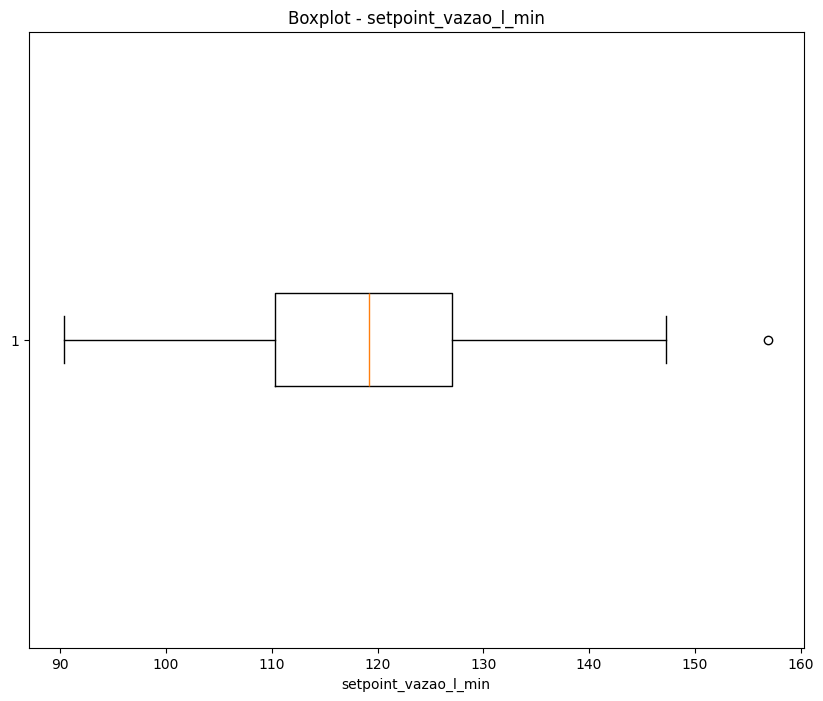

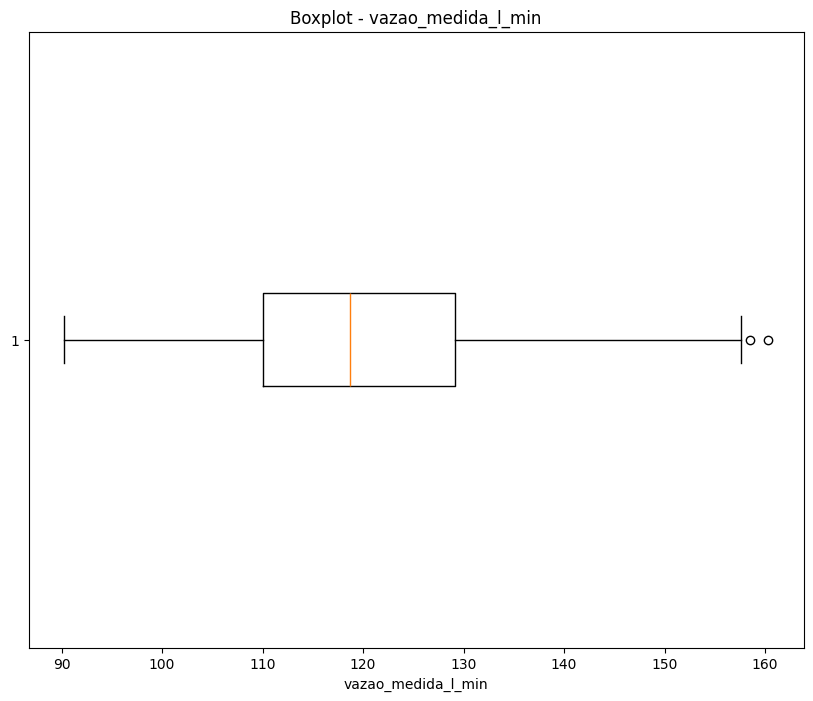

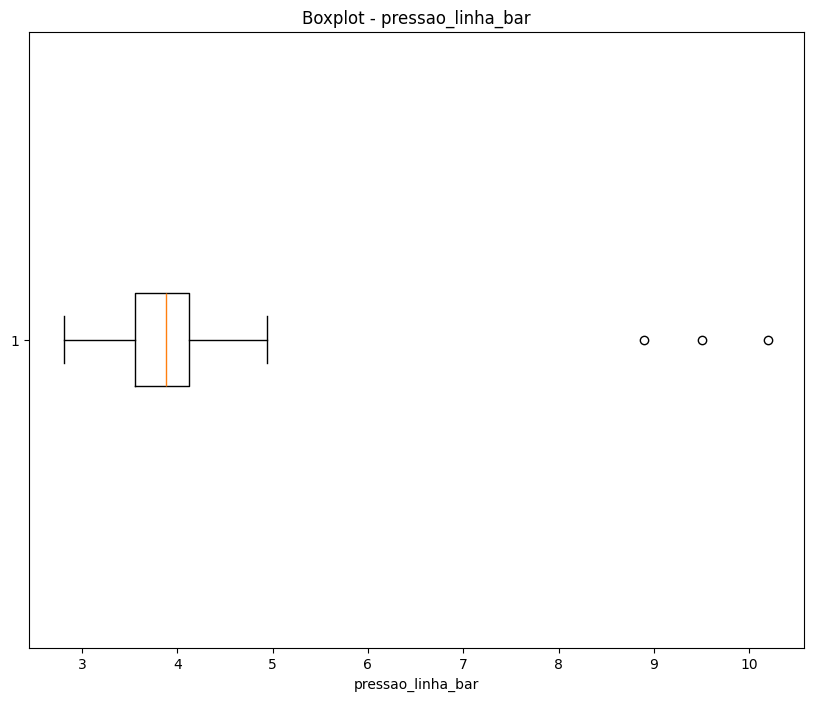

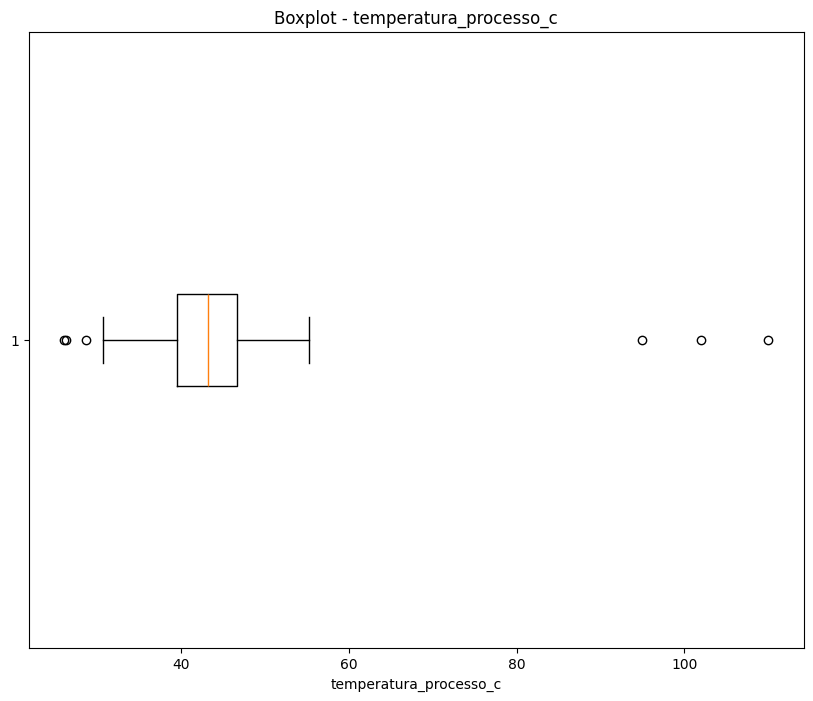

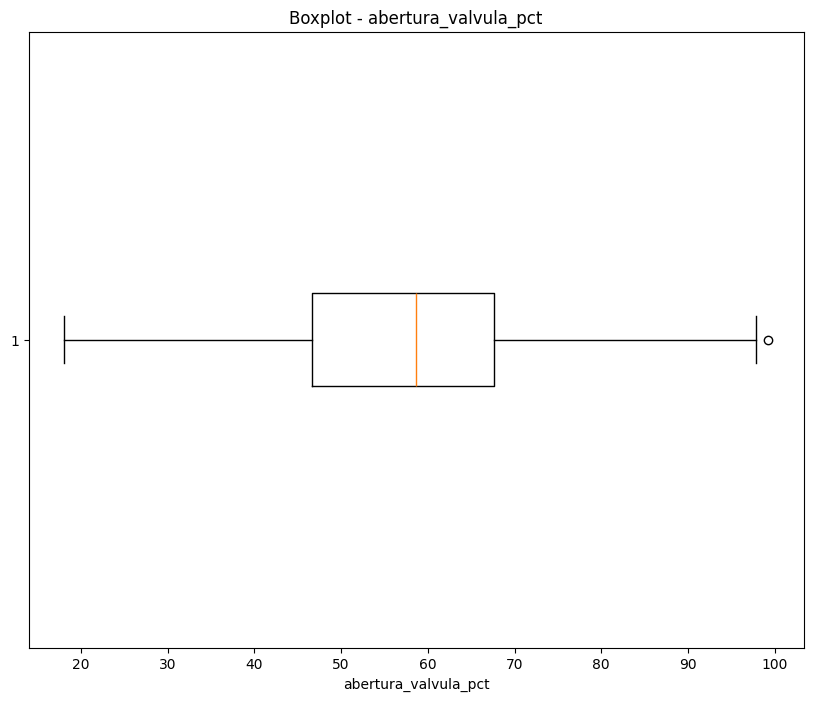

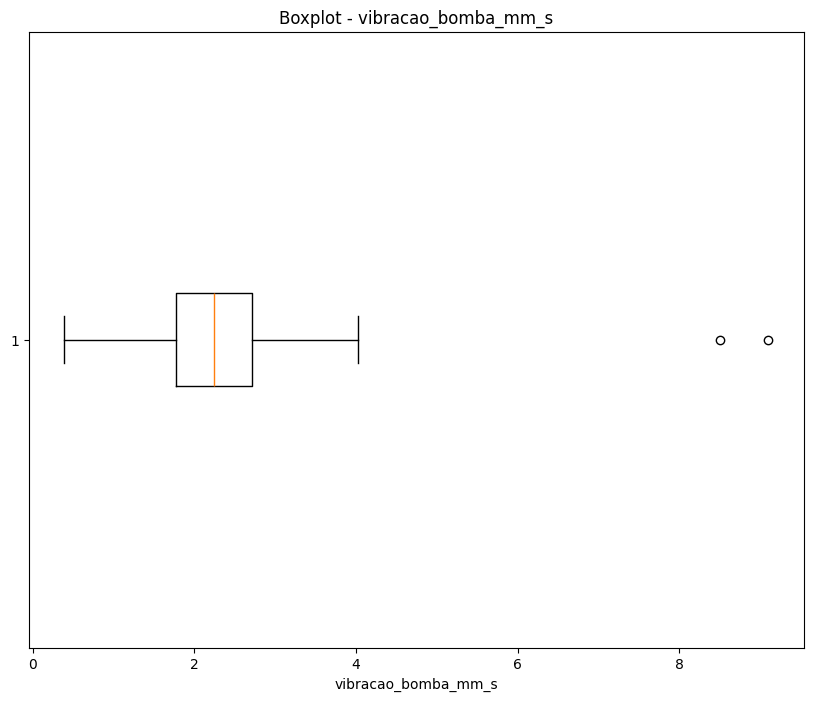

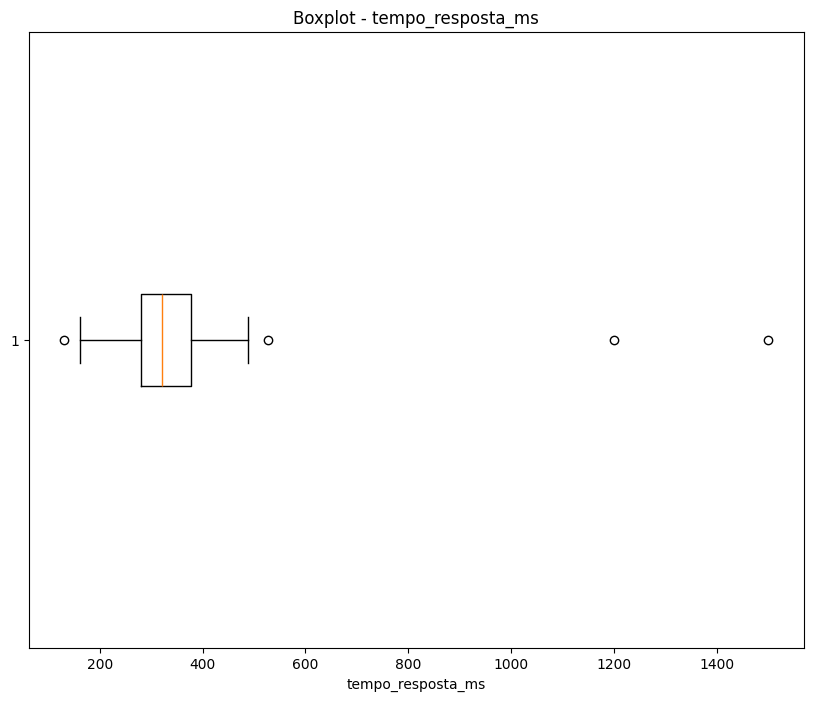

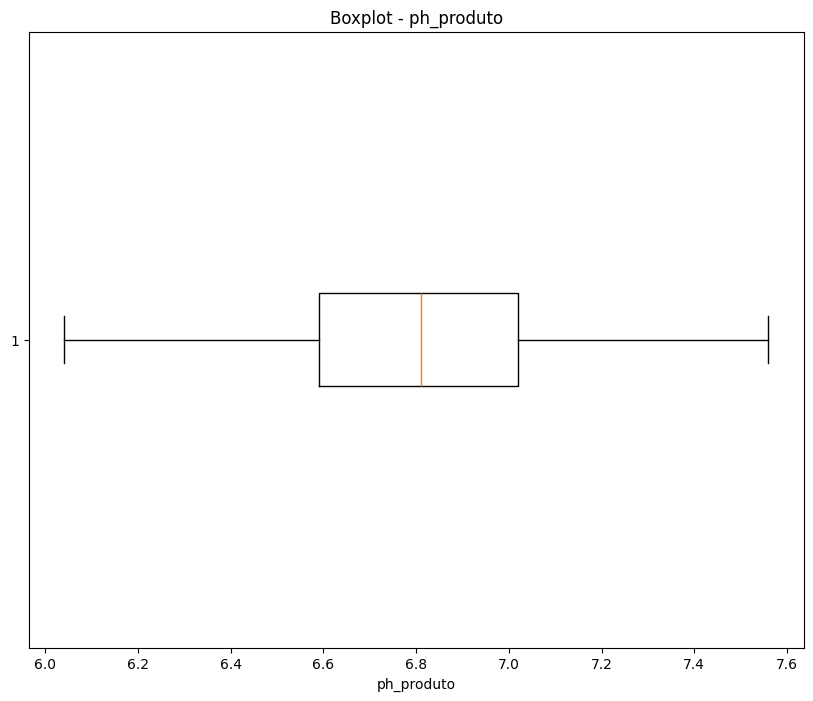

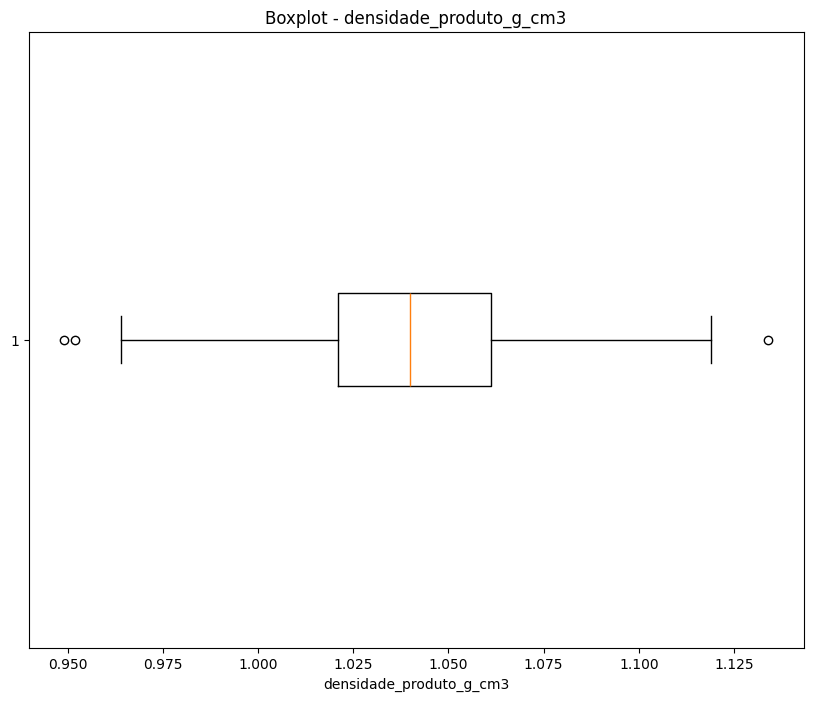

In [44]:
# Complete
# dica: crie uma lista com as colunas e use um laço para gerar os gráficos

lista_colunas=df.select_dtypes(include=['number']).columns.tolist()

for coluna in lista_colunas:
    plt.figure(figsize=(10,8))

    plt.boxplot(df[coluna].dropna(),vert=False)
    plt.title(f'Boxplot - {coluna}')
    plt.xlabel(coluna)
    plt.show()

**Anotações do aluno sobre possíveis outliers:**

- As variáveis **temperatura_processo_c** (6 outliers) e **tempo_resposta_ms** (4 outliers) foram as que apresentaram mais valores discrepantes, com temperatura chegando a 95–110°C (bem acima da faixa normal de ~29–57°C) e tempo de resposta chegando a 1200–1500 ms (faixa normal ~135–522 ms) — possíveis falhas de sensor ou eventos reais de anomalia no processo.
- **pressao_linha_bar** (3 outliers, valores de 8,9 a 10,2 bar) e **vibracao_bomba_mm_s** (2 outliers, valores de 8,5 e 9,1 mm/s) também mostraram pontos bem acima da faixa esperada, o que pode indicar problemas mecânicos ou de instrumentação na bomba/linha.
- As demais colunas (setpoint_vazao_l_min, vazao_medida_l_min, abertura_valvula_pct, densidade_produto_g_cm3) tiveram poucos outliers (1 a 3 cada) e de menor magnitude, enquanto **ph_produto** não apresentou nenhum outlier pela regra do IQR — sendo a variável mais "limpa" da base.


## 9. Correlação entre variáveis numéricas

Calcule a matriz de correlação.


In [45]:
# Complete
correlation_matrix=df.select_dtypes(include=['number']).corr()
correlation_matrix

,setpoint_vazao_l_min,vazao_medida_l_min,pressao_linha_bar,temperatura_processo_c,abertura_valvula_pct,vibracao_bomba_mm_s,tempo_resposta_ms,ph_produto,densidade_produto_g_cm3
setpoint_vazao_l_min,1.000000,0.802637,-0.094775,0.014382,0.076248,-0.127190,0.035932,0.162652,-0.032649
vazao_medida_l_min,0.802637,1.000000,0.011326,0.086975,0.079334,-0.058835,-0.052689,0.135174,-0.080550
pressao_linha_bar,-0.094775,0.011326,1.000000,-0.041621,-0.030694,-0.001777,-0.039313,-0.032101,0.072598
temperatura_processo_c,0.014382,0.086975,-0.041621,1.000000,0.000833,0.063645,-0.019068,0.020311,-0.033079
abertura_valvula_pct,0.076248,0.079334,-0.030694,0.000833,1.000000,-0.099145,-0.016843,-0.004105,-0.054148
vibracao_bomba_mm_s,-0.127190,-0.058835,-0.001777,0.063645,-0.099145,1.000000,-0.056230,-0.079424,-0.092018
tempo_resposta_ms,0.035932,-0.052689,-0.039313,-0.019068,-0.016843,-0.056230,1.000000,0.096523,0.020975
ph_produto,0.162652,0.135174,-0.032101,0.020311,-0.004105,-0.079424,0.096523,1.000000,0.000128
densidade_produto_g_cm3,-0.032649,-0.080550,0.072598,-0.033079,-0.054148,-0.092018,0.020975,0.000128,1.000000


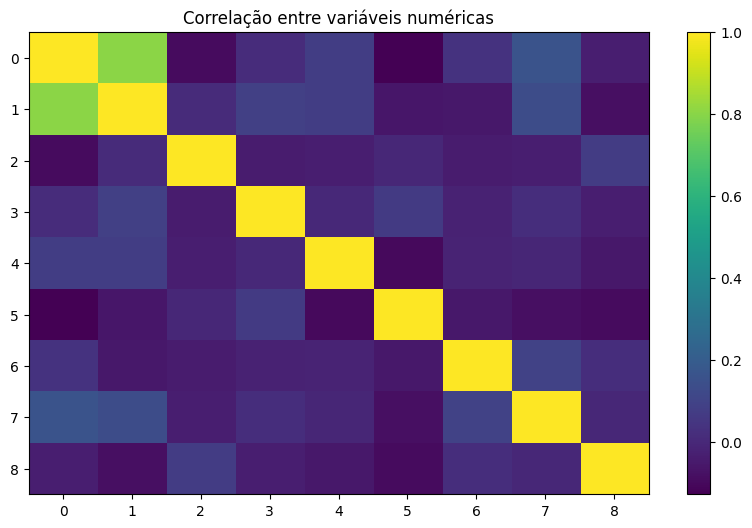

In [46]:
# Mapa de calor

plt.figure(figsize=(10,6))
plt.imshow(correlation_matrix,aspect='auto')
plt.colorbar()
plt.title('Correlação entre variáveis numéricas')
plt.show()

## 10. Criação de uma variável auxiliar

Crie uma variável com o desvio absoluto entre:
- setpoint_vazao_l_min
- vazao_medida_l_min

Nome sugerido: `desvio_vazao_abs`


In [47]:
# Criando uma variável auxiliar

df['desvio_vazao_abs']=(df['setpoint_vazao_l_min']-df['vazao_medida_l_min']).abs()

df[['setpoint_vazao_l_min','vazao_medida_l_min','desvio_vazao_abs']]


,setpoint_vazao_l_min,vazao_medida_l_min,desvio_vazao_abs
0,121.44,128.08,6.64
1,126.17,119.32,6.85
2,128.54,129.11,0.57
3,106.50,102.68,3.82
4,101.59,NaN,NaN
...,...,...,...
175,147.25,146.48,0.77
176,122.18,131.37,9.19
177,122.98,117.35,5.63
178,114.49,114.21,0.28


In [48]:
#Atividade de fechamento

resumo = {
    'linhas': df.shape[0],
    'colunas': df.shape[1],
    'duplicatas': int(df.duplicated().sum()),
    'colunas_com_faltantes': int((df.isna().sum() > 0).sum())
}

print('Resumo dos dados ')
for chave,valor in resumo.items():
  print(f'{chave}:{valor}')




Resumo dos dados 
linhas:180
colunas:16
duplicatas:0
colunas_com_faltantes:8


## 11. Interpretação técnica

Responda com base na exploração realizada:

**1. Quais problemas de qualidade de dados foram identificados?**

Dados ausentes, valores duplicados e outliers.

**2. Quais variáveis parecem críticas para avaliar a instrumentação?**

vazao_medida_l_min; tempo_resposta_ms; pressao_linha_bar; temperatura_processo_c.

Essas são variáveis de medição direta do processo (não são parâmetros configuráveis como o setpoint), então concentraram a maior parte dos valores ausentes e dos outliers detectados — problemas nelas costumam refletir falhas reais de sensores ou da instrumentação.

**3. Por que não devemos treinar um modelo imediatamente, sem inspeção?**

Dados ausentes podem gerar erros no treinamento ou viés se tratados sem critério; duplicatas fazem o modelo "aprender" o mesmo caso mais de uma vez, distorcendo padrões; e outliers podem distorcer estatísticas (média, desvio padrão) e o ajuste do modelo, levando-o a dar peso excessivo a casos raros/anômalos em vez do comportamento normal do processo.

## 12. Fechamento

Nesta aula, você começou a trabalhar o início do pipeline de Machine Learning:
- definição do problema;
- conhecimento da base;
- análise exploratória;
- identificação de problemas de qualidade.

Na próxima etapa, a base poderá ser tratada para uso em modelagem.
